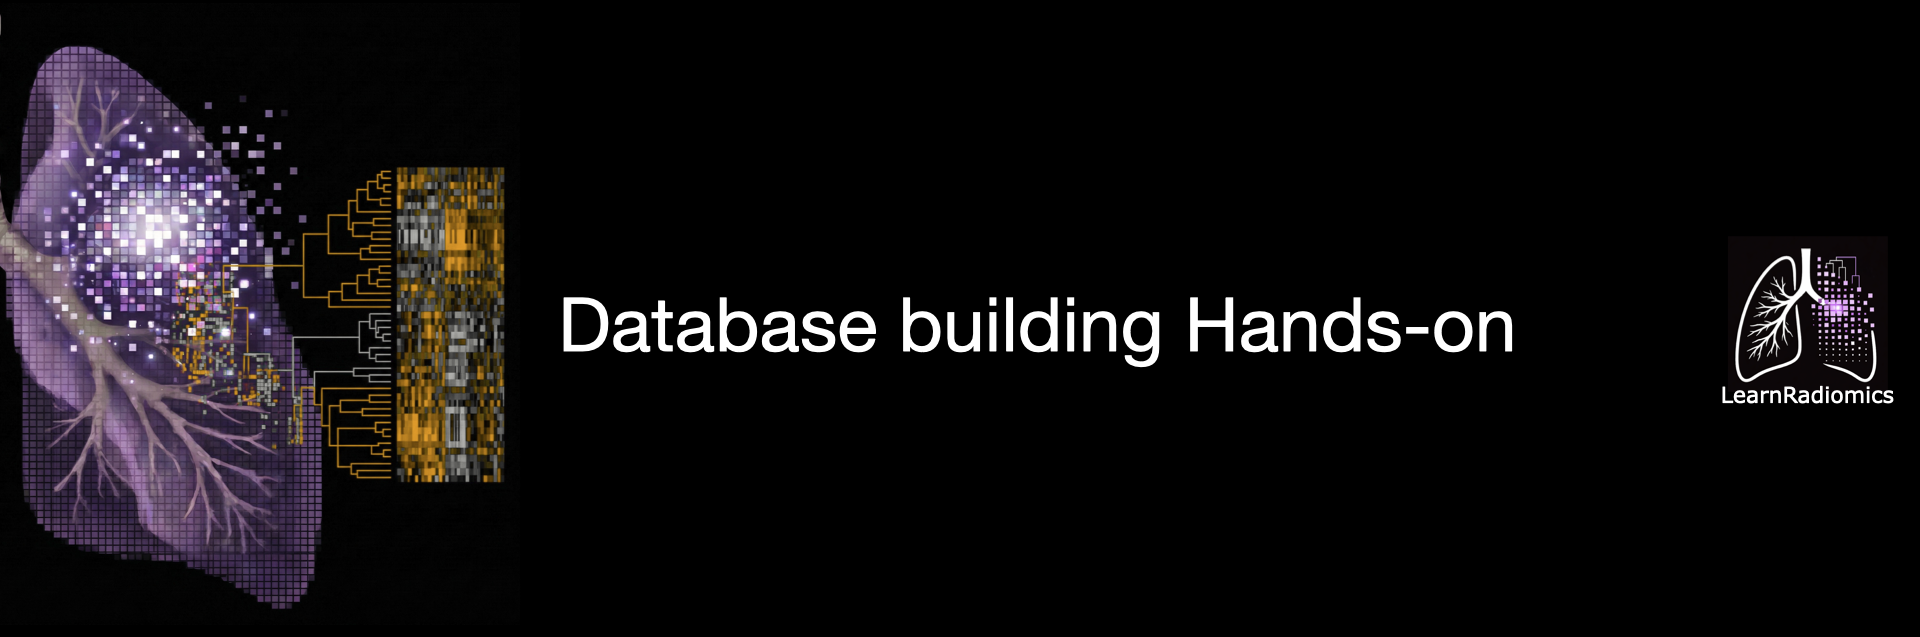

#### Dataset description:

Bakr, S., Gevaert, O., Echegaray, S., Ayers, K., Zhou, M., Shafiq, M., Zheng, H., Zhang, W., Leung, A., Kadoch, M., Shrager, J., Quon, A., Rubin, D., Plevritis, S., & Napel, S. (2017). Data for NSCLC Radiogenomics (Version 4) [Data set]. The Cancer Imaging Archive. https://doi.org/10.7937/K9/TCIA.2017.7hs46erv

License: CC BY 3.0

>>##### Radiomic Features Extracted for this Course using PyRadiomics

In [ ]:
import pandas as pd
import matplotlib .pyplot as plt
from collections import Counter
import os

## Suppress warnings
import warnings
warnings.filterwarnings ('ignore')

pd.set_option ('display.max_columns',None )
pd.set_option ('display.max_rows',None )

In [ ]:
## First, we load the database with clinical and demographic features
url ='https://raw.githubusercontent.com/learnradiomics/data_wrangling/main/DATA_LABELS_NSCLC_RADIOGENOMICS.xlsx'

clinical_data = pd.read_excel(url )

print (f"Number of rows: {clinical_data.shape[0]}, and columns: {clinical_data.shape [1 ]}")


In [ ]:
print ("Column names:", clinical_data.columns)

In [ ]:
clinical_data.head(5)

In [ ]:
### Add data with radiomics features
radiomics_features = pd.read_excel ("https://raw.githubusercontent.com/learnradiomics/data_wrangling/main/df_features_original.xlsx")

print (f"Number of rows: {radiomics_features.shape [0]}, and columns: {radiomics_features.shape[1]}")

In [ ]:
radiomics_features.columns

In [ ]:
radiomics_features.head(3)

In [ ]:
for i in range(len (radiomics_features.columns)):
    print (i ,f'var: {radiomics_features.columns[i]}')

In [ ]:
## Insert the Case ID column
radiomics_features_selected = radiomics_features.iloc[:,38 :].copy()
radiomics_features_selected.insert (loc =0 ,
                                    column ='Case ID',
                                    value =radiomics_features ['Case ID'])

radiomics_features_selected.head(5)

In [ ]:
## Filter the rows found in radiomics_features['Case ID']

clinical_data_filtered = clinical_data[clinical_data['Case ID'].isin (radiomics_features ['Case ID'])].copy()
clinical_data_filtered.shape

In [ ]:
clinical_data_filtered.head(2)

### Table operations in pandas


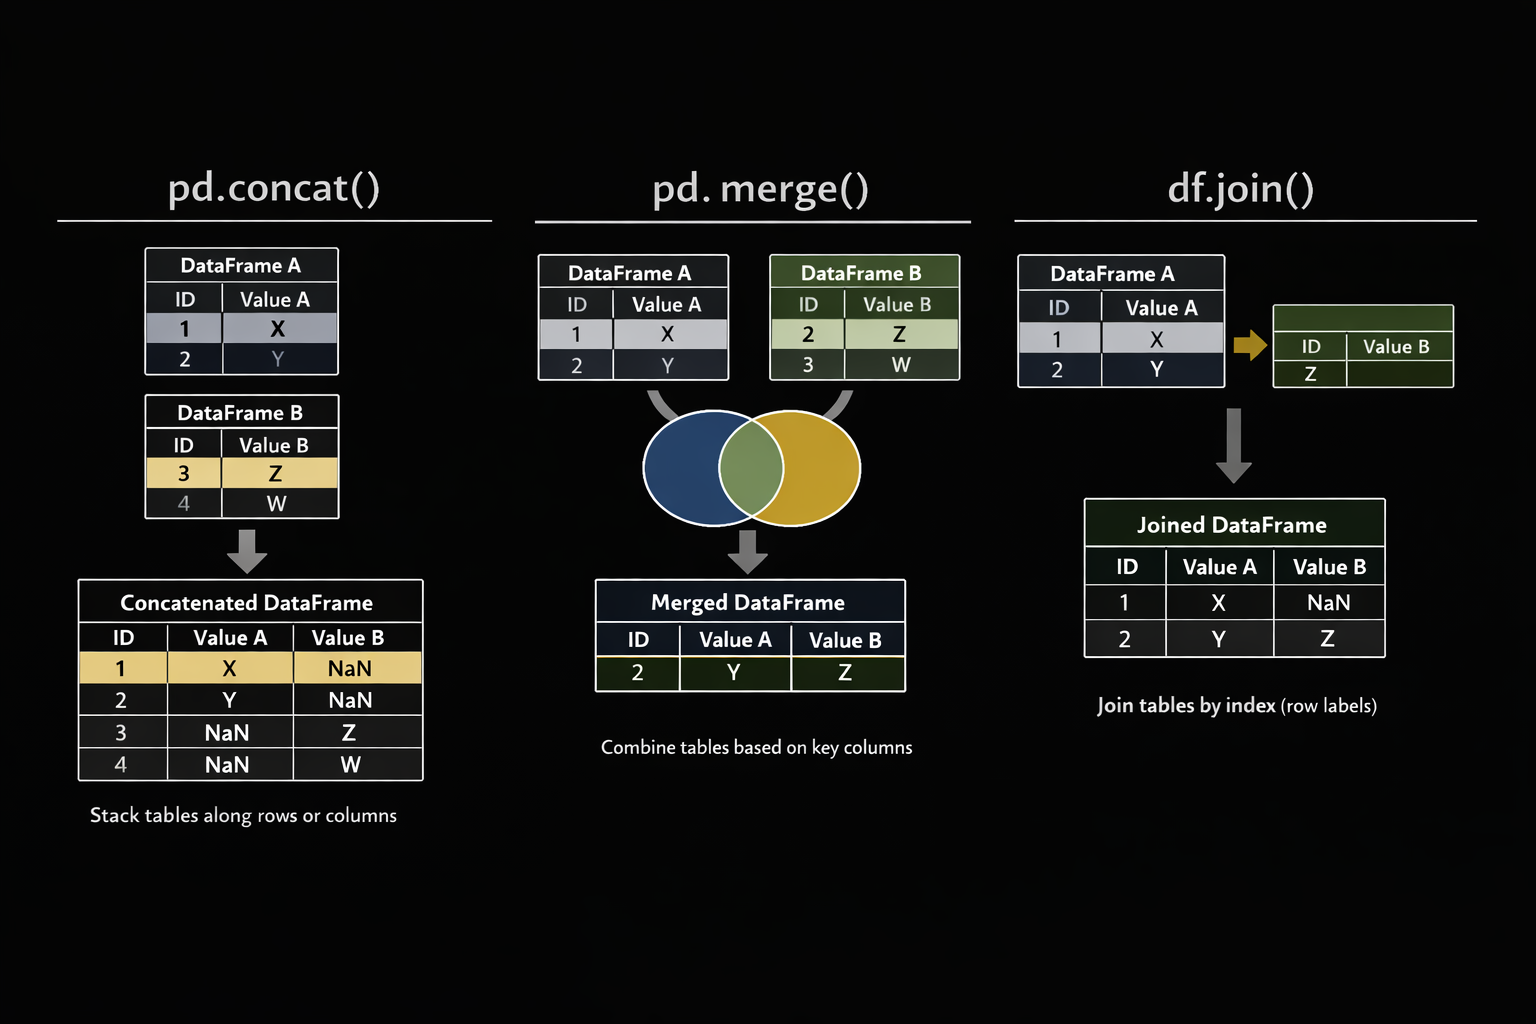

In [ ]:
table_1 = pd.DataFrame()
table_1 ['ID']=["patient_1","patient_2","patient_3","patient_4"]
table_1 ['Age']=[32 ,25 ,76 ,42 ]
table_1 ['Gender']=["M","F","M","F"]

table_2 = pd.DataFrame()
table_2 ['ID']=["patient_5","patient_6","patient_7","patient_8"]
table_2 ['Gender']=["F","F","M","M"]
table_2 ['Age']=[19 ,21 ,56 ,63 ]

table_A = pd.DataFrame()
table_A['ID']=["patient_1","patient_2","patient_3","patient_4",
               "patient_5","patient_6","patient_7","patient_8"]
table_A ['Weight']=[45 ,63 ,80 ,78 ,92 ,90 ,54 ,75 ]
table_A ['Biomarker']=[0.04 ,0.06 ,0.2 ,0.97 ,0.26 ,0.64 ,0.83 ,0.16 ]

table_B = pd.DataFrame()
table_B ['ID']=['patient_2','patient_4','patient_6','patient_8','patient_10']
table_B ['Height']=[178 ,165 ,142 ,175 ,186 ]

table_C = pd.DataFrame()
table_C ['Case_ID']=['patient_2','patient_4','patient_6','patient_8','patient_10']
table_C ['Height']=[178 ,165 ,142 ,175 ,186 ]

In [ ]:
table_1.head(5)

In [ ]:
table_2.head(5)

### Concat() function


In [ ]:
table_3 = pd.concat([table_1 ,table_2 ],ignore_index =True )
table_3

### Merge() function


In [ ]:
table_A

In [ ]:
### Tabla_3 y Tabla_A comparten columna de ID

table_3A = pd.merge (table_3 ,table_A, on ='ID', how ='inner')
table_3A.head (10)

In [ ]:
table_B

In [ ]:
## Inner -> ID intersection
table_3B = pd.merge (table_3 , table_B, on ='ID', how ='inner')
table_3B.head (10)

In [ ]:
## Left merge
table_3L = pd.merge (table_3 ,table_B ,on ='ID',how ='left')
table_3L.head(10)

In [ ]:
## Right merge
table_3R = pd.merge (table_3 , table_B , on ='ID', how ='right')
table_3R.head (10)

In [ ]:
## Inner -> ID intersection
table_AC = pd.merge (table_A ,table_C ,left_on ='ID',right_on ='Case_ID',how ='inner')
table_AC.head (10)

In [ ]:
### we can remove the repeated ID column

table_AC.drop (columns =['Case_ID'])

### Combination of clinical and radiomics data tables

In [ ]:
radiomics_data = pd.merge (clinical_data_filtered ,radiomics_features_selected ,on ='Case ID')
radiomics_data.shape

In [ ]:
## Null values
radiomics_data.isnull().sum()

In [ ]:
Counter (radiomics_data ['Pleural invasion (elastic, visceral, or parietal)'])

In [ ]:
for i in range (len (radiomics_data.columns )):
    print (i ,f". var: {radiomics_data.columns [i ]}")

In [ ]:
selected_columns = list(range (0, 7 ))
selected_columns.extend ([17, 18, 21, 22, 24, 25, 26, 33, 34, 35, 36])
selected_columns.extend (list(range(48, 155)))
print (selected_columns )

In [ ]:
final_radiomics_data = radiomics_data.iloc[:,selected_columns ].copy()
print ("Dimensiones:",final_radiomics_data.shape)
final_radiomics_data.head (5)

In [ ]:
final_radiomics_data.to_excel ('radiomics_data.xlsx',index =False )